# Compare three perturbation conditions: mask, replacement, and deletion

This notebook compares three ablation conditions on the same set of treated posts:

- **mask**
- **replacement with matched low-gap words**
- **deletion**

The notebook standardizes the three prediction files, computes comparable delta metrics, and then compares:

- signed deltas (`delta_valence`, `delta_arousal`)
- absolute deltas (`abs_delta_valence`, `abs_delta_arousal`)
- overall 2D affect-shift magnitude (`delta_affect_shift_mag`)

The main emphasis is on **magnitude of prediction change**, since the enriched high-gap set includes words with both positive-gap and negative-gap directions.

In [1]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, wilcoxon, friedmanchisquare

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

## Paths

In [2]:
REPO_ROOT = Path.cwd()

processed_dir = REPO_ROOT / ".." / "data" / "processed"

candidate_paths = {
    "mask": [
        processed_dir / "writestreak_full_with_predictions_masked.csv",
        Path("/mnt/data/writestreak_full_with_predictions_masked.csv"),
    ],
    "replacement": [
        processed_dir / "writestreak_full_with_predictions_replacement.csv",
        Path("/mnt/data/writestreak_full_with_predictions_replacement.csv"),
    ],
    "deletion": [
        processed_dir / "writestreak_full_with_predictions_deletion.csv",
        Path("/mnt/data/writestreak_full_with_predictions_deletion.csv"),
    ],
}

def first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None

paths = {k: first_existing(v) for k, v in candidate_paths.items()}
missing = [k for k, v in paths.items() if v is None]
if missing:
    raise FileNotFoundError(f"Missing files for: {missing}")

for k, v in paths.items():
    print(k, "->", v)

output_dir = REPO_ROOT / "compare_three_perturbations_outputs"
tables_dir = output_dir / "tables"
figures_dir = output_dir / "figures"
tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

mask -> c:\Users\hus44\Code\Directed-Reading-Project\notebooks\..\data\processed\writestreak_full_with_predictions_masked.csv
replacement -> c:\Users\hus44\Code\Directed-Reading-Project\notebooks\..\data\processed\writestreak_full_with_predictions_replacement.csv
deletion -> c:\Users\hus44\Code\Directed-Reading-Project\notebooks\..\data\processed\writestreak_full_with_predictions_deletion.csv


In [3]:
mask_df = pd.read_csv(paths["mask"])
replacement_df = pd.read_csv(paths["replacement"])
deletion_df = pd.read_csv(paths["deletion"])

print("mask:", mask_df.shape)
print("replacement:", replacement_df.shape)
print("deletion:", deletion_df.shape)

mask: (6482, 55)
replacement: (6482, 19)
deletion: (6482, 19)


In [4]:

def standardize_mask(df):
    out = df.copy()
    out = out.rename(columns={
        "pred_valence_1_9_x": "baseline_valence",
        "pred_arousal_1_9_x": "baseline_arousal",
        "pred_valence_1_9_y": "cf_valence",
        "pred_arousal_1_9_y": "cf_arousal",
    })
    out["original_post_id"] = out["post_id"].astype(str)
    out["cf_post_id"] = out["post_id"].astype(str) + "__mask"
    out["perturbation"] = "mask"
    out["selected_hits_str"] = out["selected_hits"].astype(str)
    return out

def standardize_repl_or_del(df, perturbation_name):
    out = df.copy()
    out = out.rename(columns={
        "pred_valence_1_9_x": "baseline_valence",
        "pred_arousal_1_9_x": "baseline_arousal",
        "pred_valence_1_9_y": "cf_valence",
        "pred_arousal_1_9_y": "cf_arousal",
    })
    out["cf_post_id"] = out["post_id"].astype(str)
    out["perturbation"] = perturbation_name
    return out

mask_std = standardize_mask(mask_df)
repl_std = standardize_repl_or_del(replacement_df, "replacement_lowgap")
del_std = standardize_repl_or_del(deletion_df, "deletion")

common_cols = [
    "original_post_id", "cf_post_id", "user_id", "created_at", "perturbation",
    "baseline_valence", "baseline_arousal", "cf_valence", "cf_arousal",
    "selected_hit_count", "selected_hit_type_count", "selected_hit_prop",
    "has_selected_high_gap_word", "selected_hits_str"
]

for name, df_ in [("mask", mask_std), ("replacement", repl_std), ("deletion", del_std)]:
    missing = [c for c in common_cols if c not in df_.columns]
    if missing:
        raise ValueError(f"{name} is missing columns after standardization: {missing}")

mask_std = mask_std[common_cols].copy()
repl_std = repl_std[common_cols].copy()
del_std = del_std[common_cols].copy()

combined = pd.concat([mask_std, repl_std, del_std], ignore_index=True)
combined.head()

,original_post_id,cf_post_id,user_id,created_at,perturbation,baseline_valence,baseline_arousal,cf_valence,cf_arousal,selected_hit_count,selected_hit_type_count,selected_hit_prop,has_selected_high_gap_word,selected_hits_str
0,kk1866,kk1866__mask,000a672e1864051f,2020-12-25 16:01:26+00:00,mask,6.832933,4.805484,6.815926,4.751316,1,1,0.008696,1,['special']
1,18sthvq,18sthvq__mask,002305cde36be93b,2023-12-28 13:06:30+00:00,mask,5.790307,8.743247,5.771897,8.740696,1,1,0.002513,1,['fresh']
2,18tq0cp,18tq0cp__mask,002305cde36be93b,2023-12-29 15:44:48+00:00,mask,4.755822,6.276048,4.675831,6.333640,1,1,0.125000,1,['good']
3,18vcv2t,18vcv2t__mask,002305cde36be93b,2023-12-31 17:42:39+00:00,mask,5.946425,4.145765,5.957864,4.158699,1,1,0.005917,1,['normal']
4,18xqnzc,18xqnzc__mask,002305cde36be93b,2024-01-03 18:49:33+00:00,mask,3.756989,6.613257,3.702392,6.460042,1,1,0.015873,1,['option']


## Compute comparable delta metrics

In [5]:

combined["delta_valence"] = combined["baseline_valence"] - combined["cf_valence"]
combined["delta_arousal"] = combined["baseline_arousal"] - combined["cf_arousal"]

combined["abs_delta_valence"] = combined["delta_valence"].abs()
combined["abs_delta_arousal"] = combined["delta_arousal"].abs()
combined["delta_affect_shift_mag"] = np.sqrt(
    combined["delta_valence"] ** 2 + combined["delta_arousal"] ** 2
)

combined["baseline_affect_mag"] = np.sqrt(
    combined["baseline_valence"] ** 2 + combined["baseline_arousal"] ** 2
)

combined.head()

,original_post_id,cf_post_id,user_id,created_at,perturbation,baseline_valence,baseline_arousal,cf_valence,cf_arousal,selected_hit_count,selected_hit_type_count,selected_hit_prop,has_selected_high_gap_word,selected_hits_str,delta_valence,delta_arousal,abs_delta_valence,abs_delta_arousal,delta_affect_shift_mag,baseline_affect_mag
0,kk1866,kk1866__mask,000a672e1864051f,2020-12-25 16:01:26+00:00,mask,6.832933,4.805484,6.815926,4.751316,1,1,0.008696,1,['special'],0.017007,0.054168,0.017007,0.054168,0.056775,8.353541
1,18sthvq,18sthvq__mask,002305cde36be93b,2023-12-28 13:06:30+00:00,mask,5.790307,8.743247,5.771897,8.740696,1,1,0.002513,1,['fresh'],0.018410,0.002551,0.018410,0.002551,0.018586,10.486755
2,18tq0cp,18tq0cp__mask,002305cde36be93b,2023-12-29 15:44:48+00:00,mask,4.755822,6.276048,4.675831,6.333640,1,1,0.125000,1,['good'],0.079990,-0.057591,0.079990,0.057591,0.098566,7.874428
3,18vcv2t,18vcv2t__mask,002305cde36be93b,2023-12-31 17:42:39+00:00,mask,5.946425,4.145765,5.957864,4.158699,1,1,0.005917,1,['normal'],-0.011439,-0.012934,0.011439,0.012934,0.017267,7.248954
4,18xqnzc,18xqnzc__mask,002305cde36be93b,2024-01-03 18:49:33+00:00,mask,3.756989,6.613257,3.702392,6.460042,1,1,0.015873,1,['option'],0.054598,0.153215,0.054598,0.153215,0.162652,7.605928


## Sanity checks

In [6]:

sanity = (
    combined.groupby("perturbation", as_index=False)
    .agg(
        n_rows=("original_post_id", "size"),
        n_unique_posts=("original_post_id", "nunique"),
        n_users=("user_id", "nunique"),
        mean_hit_count=("selected_hit_count", "mean"),
        mean_hit_prop=("selected_hit_prop", "mean"),
    )
)

display(sanity)

overlap_posts = (
    combined.groupby("original_post_id")["perturbation"]
    .nunique()
    .value_counts()
    .sort_index()
    .rename_axis("n_conditions_present")
    .reset_index(name="n_posts")
)
display(overlap_posts)

,perturbation,n_rows,n_unique_posts,n_users,mean_hit_count,mean_hit_prop
0,deletion,6482,6482,602,1.636223,0.011594
1,mask,6482,6482,602,1.636223,0.011594
2,replacement_lowgap,6482,6482,602,1.636223,0.011594


,n_conditions_present,n_posts
0,3,6482


## Main summaries

In [7]:

summary = (
    combined.groupby("perturbation", as_index=False)
    .agg(
        n_posts=("original_post_id", "nunique"),
        mean_abs_delta_valence=("abs_delta_valence", "mean"),
        median_abs_delta_valence=("abs_delta_valence", "median"),
        mean_abs_delta_arousal=("abs_delta_arousal", "mean"),
        median_abs_delta_arousal=("abs_delta_arousal", "median"),
        mean_delta_affect_shift_mag=("delta_affect_shift_mag", "mean"),
        median_delta_affect_shift_mag=("delta_affect_shift_mag", "median"),
        mean_signed_delta_valence=("delta_valence", "mean"),
        mean_signed_delta_arousal=("delta_arousal", "mean"),
    )
    .sort_values("mean_delta_affect_shift_mag", ascending=False)
)

display(summary)
summary.to_csv(tables_dir / "summary_by_perturbation.csv", index=False)

,perturbation,n_posts,mean_abs_delta_valence,median_abs_delta_valence,mean_abs_delta_arousal,median_abs_delta_arousal,mean_delta_affect_shift_mag,median_delta_affect_shift_mag,mean_signed_delta_valence,mean_signed_delta_arousal
2,replacement_lowgap,6482,0.108619,0.070216,0.082353,0.054277,0.150796,0.113701,-0.010885,-0.027775
1,mask,6482,0.089854,0.063622,0.082337,0.059410,0.135192,0.106899,-0.024938,-0.029613
0,deletion,6482,0.078463,0.053858,0.077159,0.055321,0.122519,0.094222,-0.020797,-0.026556


## Pairwise comparisons on the same original posts

The cleanest comparison uses only posts that appear under all three conditions.

In [8]:

paired = combined.pivot_table(
    index="original_post_id",
    columns="perturbation",
    values=["abs_delta_valence", "abs_delta_arousal", "delta_affect_shift_mag",
            "delta_valence", "delta_arousal"],
    aggfunc="first"
)

# keep only complete cases across the three conditions for all main magnitude metrics
main_needed = [
    ("abs_delta_valence", "mask"),
    ("abs_delta_valence", "replacement_lowgap"),
    ("abs_delta_valence", "deletion"),
    ("abs_delta_arousal", "mask"),
    ("abs_delta_arousal", "replacement_lowgap"),
    ("abs_delta_arousal", "deletion"),
    ("delta_affect_shift_mag", "mask"),
    ("delta_affect_shift_mag", "replacement_lowgap"),
    ("delta_affect_shift_mag", "deletion"),
]

paired_complete = paired.dropna(subset=main_needed).copy()
print("Posts with all three conditions available:", len(paired_complete))
paired_complete.head()

Posts with all three conditions available: 6482


abs_delta_arousal                               \
perturbation              deletion      mask replacement_lowgap   
original_post_id                                                  
1005dix                   0.096970  0.106776           0.117101   
1007zmq                   0.139147  0.092102           0.001391   
100epvl                   0.052869  0.023160           0.076594   
100klgx                   0.031737  0.033321           0.040742   
100sblq                   0.025100  0.005856           0.033689   

                 abs_delta_valence                               \
perturbation              deletion      mask replacement_lowgap   
original_post_id                                                  
1005dix                   0.058392  0.082301           0.072655   
1007zmq                   0.056957  0.189130           0.087719   
100epvl                   0.037555  0.031353           0.044676   
100klgx                   0.104756  0.183958           0.198561   
100sblq                   0.034269  0.006880           0.075440   

                 delta_affect_shift_mag                               \
perturbation                   deletion      mask replacement_lowgap   
original_post_id                                                       
1005dix                        0.113194  0.134813           0.137809   
1007zmq                        0.150353  0.210364           0.087730   
100epvl                        0.064850  0.038979           0.088671   
100klgx                        0.109458  0.186952           0.202698   
100sblq                        0.042478  0.009035           0.082620   

                 delta_arousal                              delta_valence  \
perturbation          deletion      mask replacement_lowgap      deletion   
original_post_id                                                            
1005dix              -0.096970 -0.106776          -0.117101     -0.058392   
1007zmq               0.139147  0.092102          -0.001391      0.056957   
100epvl              -0.052869 -0.023160          -0.076594      0.037555   
100klgx              -0.031737 -0.033321          -0.040742     -0.104756   
100sblq               0.025100  0.005856          -0.033689     -0.034269   

                                               
perturbation          mask replacement_lowgap  
original_post_id                               
1005dix          -0.082301          -0.072655  
1007zmq           0.189130           0.087719  
100epvl           0.031353           0.044676  
100klgx          -0.183958          -0.198561  
100sblq          -0.006880          -0.075440

In [9]:

pairwise_rows = []

def add_wilcoxon(metric, a, b, label_a, label_b):
    sub = paired_complete[(metric, a)].dropna().index.intersection(
        paired_complete[(metric, b)].dropna().index
    )
    x = paired_complete.loc[sub, (metric, a)].astype(float)
    y = paired_complete.loc[sub, (metric, b)].astype(float)
    stat, p = wilcoxon(x, y)
    pairwise_rows.append({
        "metric": metric,
        "condition_a": label_a,
        "condition_b": label_b,
        "n": int(len(sub)),
        "mean_a": float(x.mean()),
        "mean_b": float(y.mean()),
        "mean_diff_a_minus_b": float((x - y).mean()),
        "wilcoxon_stat": float(stat),
        "p_value": float(p),
    })

for metric in ["abs_delta_valence", "abs_delta_arousal", "delta_affect_shift_mag"]:
    add_wilcoxon(metric, "mask", "replacement_lowgap", "mask", "replacement_lowgap")
    add_wilcoxon(metric, "mask", "deletion", "mask", "deletion")
    add_wilcoxon(metric, "replacement_lowgap", "deletion", "replacement_lowgap", "deletion")

pairwise_df = pd.DataFrame(pairwise_rows)
display(pairwise_df)
pairwise_df.to_csv(tables_dir / "pairwise_wilcoxon_comparisons.csv", index=False)

,metric,condition_a,condition_b,n,mean_a,mean_b,mean_diff_a_minus_b,wilcoxon_stat,p_value
0,abs_delta_valence,mask,replacement_lowgap,6482,0.089854,0.108619,-0.018765,8629083.0,1.309226e-35
1,abs_delta_valence,mask,deletion,6482,0.089854,0.078463,0.011391,7978720.0,3.926363e-63
2,abs_delta_valence,replacement_lowgap,deletion,6482,0.108619,0.078463,0.030155,6659899.0,1.043716e-143
3,abs_delta_arousal,mask,replacement_lowgap,6482,0.082337,0.082353,-0.000016,10016088.0,1.155665e-03
4,abs_delta_arousal,mask,deletion,6482,0.082337,0.077159,0.005178,9219057.0,1.347360e-17
5,abs_delta_arousal,replacement_lowgap,deletion,6482,0.082353,0.077159,0.005194,10224649.0,6.212998e-02
6,delta_affect_shift_mag,mask,replacement_lowgap,6482,0.135192,0.150796,-0.015604,9219550.0,1.386049e-17
7,delta_affect_shift_mag,mask,deletion,6482,0.135192,0.122519,0.012673,7862055.0,6.372457e-69
8,delta_affect_shift_mag,replacement_lowgap,deletion,6482,0.150796,0.122519,0.028277,7380620.0,1.465793e-95


## Overall repeated-measures test across the three conditions

In [10]:

friedman_rows = []

for metric in ["abs_delta_valence", "abs_delta_arousal", "delta_affect_shift_mag"]:
    x = paired_complete[(metric, "mask")].astype(float)
    y = paired_complete[(metric, "replacement_lowgap")].astype(float)
    z = paired_complete[(metric, "deletion")].astype(float)
    stat, p = friedmanchisquare(x, y, z)
    friedman_rows.append({
        "metric": metric,
        "n": int(len(paired_complete)),
        "friedman_stat": float(stat),
        "p_value": float(p),
        "mean_mask": float(x.mean()),
        "mean_replacement": float(y.mean()),
        "mean_deletion": float(z.mean()),
    })

friedman_df = pd.DataFrame(friedman_rows)
display(friedman_df)
friedman_df.to_csv(tables_dir / "friedman_three_condition_tests.csv", index=False)

,metric,n,friedman_stat,p_value,mean_mask,mean_replacement,mean_deletion
0,abs_delta_valence,6482,508.855292,3.187700e-111,0.089854,0.108619,0.078463
1,abs_delta_arousal,6482,41.157667,1.155383e-09,0.082337,0.082353,0.077159
2,delta_affect_shift_mag,6482,374.082073,5.876380e-82,0.135192,0.150796,0.122519


## Stratified comparisons by hit count, hit type count, and selected-hit proportion

These sections break the three perturbation conditions apart by:
- `selected_hit_count`
- `selected_hit_type_count`
- `selected_hit_prop`

This makes it easier to see whether the relative strength of mask, replacement, and deletion changes as lexical exposure increases.

In [11]:
# Create proportion bins using the unique original-post values, then merge back.
post_strata = (
    combined[["original_post_id", "selected_hit_count", "selected_hit_type_count", "selected_hit_prop"]]
    .drop_duplicates("original_post_id")
    .copy()
)

# Quintile-style bins for selected-hit proportion among treated posts.
n_unique_prop = post_strata["selected_hit_prop"].nunique()
q = min(5, int(n_unique_prop)) if n_unique_prop > 1 else 1
if q > 1:
    post_strata["selected_hit_prop_bin"] = pd.qcut(
        post_strata["selected_hit_prop"],
        q=q,
        duplicates="drop"
    ).astype(str)
else:
    post_strata["selected_hit_prop_bin"] = "all"

combined = combined.drop(columns=["selected_hit_prop_bin"], errors="ignore").merge(
    post_strata[["original_post_id", "selected_hit_prop_bin"]],
    on="original_post_id",
    how="left",
    validate="many_to_one"
)

# 1) Exact hit-count split
hit_count_summary = (
    combined.groupby(["perturbation", "selected_hit_count"], as_index=False)
    .agg(
        n_posts=("original_post_id", "count"),
        mean_abs_delta_valence=("abs_delta_valence", "mean"),
        mean_abs_delta_arousal=("abs_delta_arousal", "mean"),
        mean_delta_affect_shift_mag=("delta_affect_shift_mag", "mean"),
        median_delta_affect_shift_mag=("delta_affect_shift_mag", "median"),
        mean_selected_hit_prop=("selected_hit_prop", "mean"),
    )
    .sort_values(["selected_hit_count", "perturbation"])
)

# 2) Exact hit-type-count split
hit_type_summary = (
    combined.groupby(["perturbation", "selected_hit_type_count"], as_index=False)
    .agg(
        n_posts=("original_post_id", "count"),
        mean_abs_delta_valence=("abs_delta_valence", "mean"),
        mean_abs_delta_arousal=("abs_delta_arousal", "mean"),
        mean_delta_affect_shift_mag=("delta_affect_shift_mag", "mean"),
        median_delta_affect_shift_mag=("delta_affect_shift_mag", "median"),
        mean_selected_hit_prop=("selected_hit_prop", "mean"),
    )
    .sort_values(["selected_hit_type_count", "perturbation"])
)

# 3) Selected-hit-proportion-bin split
hit_prop_bin_summary = (
    combined.groupby(["perturbation", "selected_hit_prop_bin"], as_index=False)
    .agg(
        n_posts=("original_post_id", "count"),
        mean_selected_hit_prop=("selected_hit_prop", "mean"),
        mean_abs_delta_valence=("abs_delta_valence", "mean"),
        mean_abs_delta_arousal=("abs_delta_arousal", "mean"),
        mean_delta_affect_shift_mag=("delta_affect_shift_mag", "mean"),
        median_delta_affect_shift_mag=("delta_affect_shift_mag", "median"),
    )
    .sort_values(["selected_hit_prop_bin", "perturbation"])
)

display(hit_count_summary.head(20))
display(hit_type_summary.head(20))
display(hit_prop_bin_summary.head(20))

hit_count_summary.to_csv(tables_dir / "summary_by_hit_count_and_perturbation.csv", index=False)
hit_type_summary.to_csv(tables_dir / "summary_by_hit_type_count_and_perturbation.csv", index=False)
hit_prop_bin_summary.to_csv(tables_dir / "summary_by_hit_prop_bin_and_perturbation.csv", index=False)

,perturbation,selected_hit_count,n_posts,mean_abs_delta_valence,mean_abs_delta_arousal,mean_delta_affect_shift_mag,median_delta_affect_shift_mag,mean_selected_hit_prop
0,deletion,1,4057,0.057003,0.057525,0.089653,0.080729,0.009275
13,mask,1,4057,0.069011,0.064232,0.104113,0.088786,0.009275
26,replacement_lowgap,1,4057,0.081799,0.064292,0.114806,0.089576,0.009275
1,deletion,2,1487,0.091342,0.091592,0.143721,0.118384,0.013672
14,mask,2,1487,0.104267,0.094035,0.155541,0.135353,0.013672
27,replacement_lowgap,2,1487,0.125738,0.093128,0.172618,0.147024,0.013672
2,deletion,3,553,0.126364,0.123885,0.198399,0.166610,0.016490
15,mask,3,553,0.142870,0.124921,0.212007,0.186933,0.016490
28,replacement_lowgap,3,553,0.171725,0.117168,0.229173,0.183877,0.016490
3,deletion,4,207,0.170820,0.142794,0.250972,0.212547,0.018395


,perturbation,selected_hit_type_count,n_posts,mean_abs_delta_valence,mean_abs_delta_arousal,mean_delta_affect_shift_mag,median_delta_affect_shift_mag,mean_selected_hit_prop
0,deletion,1,4895,0.070228,0.070179,0.110116,0.087445,0.010533
5,mask,1,4895,0.081100,0.075258,0.122405,0.098409,0.010533
10,replacement_lowgap,1,4895,0.101014,0.074932,0.138418,0.101861,0.010533
1,deletion,2,1285,0.098501,0.091724,0.150625,0.118588,0.014458
6,mask,2,1285,0.112969,0.097956,0.166254,0.140095,0.014458
11,replacement_lowgap,2,1285,0.128364,0.097204,0.179169,0.143494,0.014458
2,deletion,3,251,0.126384,0.131542,0.207436,0.160644,0.016613
7,mask,3,251,0.136032,0.133607,0.216013,0.180794,0.016613
12,replacement_lowgap,3,251,0.141354,0.136872,0.223589,0.180825,0.016613
3,deletion,4,45,0.119518,0.103190,0.171342,0.161799,0.015950


,perturbation,selected_hit_prop_bin,n_posts,mean_selected_hit_prop,mean_abs_delta_valence,mean_abs_delta_arousal,mean_delta_affect_shift_mag,median_delta_affect_shift_mag
0,deletion,"(0.00010000000000000005, 0.00488]",1304,0.003573,0.046184,0.048969,0.075484,0.067018
5,mask,"(0.00010000000000000005, 0.00488]",1304,0.003573,0.055474,0.054584,0.086510,0.073529
10,replacement_lowgap,"(0.00010000000000000005, 0.00488]",1304,0.003573,0.068230,0.051379,0.094975,0.071350
1,deletion,"(0.00488, 0.00709]",1295,0.005996,0.060401,0.056887,0.091925,0.082619
6,mask,"(0.00488, 0.00709]",1295,0.005996,0.070655,0.062871,0.104791,0.088045
11,replacement_lowgap,"(0.00488, 0.00709]",1295,0.005996,0.088869,0.061959,0.119598,0.094028
2,deletion,"(0.00709, 0.01]",1295,0.008434,0.073935,0.067917,0.111174,0.092524
7,mask,"(0.00709, 0.01]",1295,0.008434,0.083309,0.074862,0.124558,0.104748
12,replacement_lowgap,"(0.00709, 0.01]",1295,0.008434,0.099317,0.074410,0.137040,0.107075
3,deletion,"(0.01, 0.0154]",1291,0.012274,0.088409,0.083839,0.136065,0.109462


In [12]:
# Per-perturbation correlations for each exposure variable
corr_rows = []

for pert, g in combined.groupby("perturbation"):
    for x_col in ["selected_hit_count", "selected_hit_type_count", "selected_hit_prop"]:
        for y_col in ["abs_delta_valence", "abs_delta_arousal", "delta_affect_shift_mag"]:
            sub = g[[x_col, y_col]].dropna()
            if len(sub) >= 3 and sub[x_col].nunique() > 1 and sub[y_col].nunique() > 1:
                rho, p = spearmanr(sub[x_col], sub[y_col])
            else:
                rho, p = np.nan, np.nan

            corr_rows.append({
                "perturbation": pert,
                "x": x_col,
                "y": y_col,
                "n": int(len(sub)),
                "spearman_rho": float(rho) if pd.notna(rho) else np.nan,
                "p_value": float(p) if pd.notna(p) else np.nan,
            })

corr_df = pd.DataFrame(corr_rows)
display(corr_df)
corr_df.to_csv(tables_dir / "correlations_by_perturbation.csv", index=False)

# Within-stratum paired comparisons across perturbations
paired_wide = combined.pivot_table(
    index="original_post_id",
    columns="perturbation",
    values=["abs_delta_valence", "abs_delta_arousal", "delta_affect_shift_mag"],
    aggfunc="first"
)

paired_wide.columns = [f"{m}__{p}" for m, p in paired_wide.columns]
paired_wide = paired_wide.reset_index().merge(
    post_strata[["original_post_id", "selected_hit_count", "selected_hit_type_count", "selected_hit_prop_bin"]],
    on="original_post_id",
    how="left",
    validate="one_to_one"
)

def stratified_pairwise_tests(df, strata_col, metrics=("abs_delta_valence", "abs_delta_arousal", "delta_affect_shift_mag")):
    rows = []
    pairs = [
        ("mask", "replacement_lowgap"),
        ("mask", "deletion"),
        ("replacement_lowgap", "deletion"),
    ]
    for level, g in df.groupby(strata_col):
        for metric in metrics:
            for a, b in pairs:
                col_a = f"{metric}__{a}"
                col_b = f"{metric}__{b}"
                sub = g[[col_a, col_b]].dropna()
                if len(sub) < 5:
                    rows.append({
                        "strata_col": strata_col,
                        "strata_level": str(level),
                        "metric": metric,
                        "comparison": f"{a} vs {b}",
                        "n_pairs": int(len(sub)),
                        "mean_a": sub[col_a].mean() if len(sub) else np.nan,
                        "mean_b": sub[col_b].mean() if len(sub) else np.nan,
                        "mean_diff_a_minus_b": (sub[col_a] - sub[col_b]).mean() if len(sub) else np.nan,
                        "wilcoxon_stat": np.nan,
                        "p_value": np.nan,
                    })
                    continue
                try:
                    stat, p = wilcoxon(sub[col_a], sub[col_b], zero_method="wilcox", alternative="two-sided")
                except Exception:
                    stat, p = np.nan, np.nan
                rows.append({
                    "strata_col": strata_col,
                    "strata_level": str(level),
                    "metric": metric,
                    "comparison": f"{a} vs {b}",
                    "n_pairs": int(len(sub)),
                    "mean_a": float(sub[col_a].mean()),
                    "mean_b": float(sub[col_b].mean()),
                    "mean_diff_a_minus_b": float((sub[col_a] - sub[col_b]).mean()),
                    "wilcoxon_stat": float(stat) if pd.notna(stat) else np.nan,
                    "p_value": float(p) if pd.notna(p) else np.nan,
                })
    return pd.DataFrame(rows)

stratified_pairwise = pd.concat([
    stratified_pairwise_tests(paired_wide, "selected_hit_count"),
    stratified_pairwise_tests(paired_wide, "selected_hit_type_count"),
    stratified_pairwise_tests(paired_wide, "selected_hit_prop_bin"),
], ignore_index=True)

display(stratified_pairwise.head(30))
stratified_pairwise.to_csv(tables_dir / "stratified_pairwise_comparisons.csv", index=False)

,perturbation,x,y,n,spearman_rho,p_value
0,deletion,selected_hit_count,abs_delta_valence,6482,0.278163,1.711322e-115
1,deletion,selected_hit_count,abs_delta_arousal,6482,0.269280,4.405715e-108
2,deletion,selected_hit_count,delta_affect_shift_mag,6482,0.392533,8.826204e-238
3,deletion,selected_hit_type_count,abs_delta_valence,6482,0.143054,5.534953e-31
4,deletion,selected_hit_type_count,abs_delta_arousal,6482,0.131579,1.988095e-26
5,deletion,selected_hit_type_count,delta_affect_shift_mag,6482,0.206105,3.986234e-63
6,deletion,selected_hit_prop,abs_delta_valence,6482,0.290556,2.654155e-126
7,deletion,selected_hit_prop,abs_delta_arousal,6482,0.299893,8.170483e-135
8,deletion,selected_hit_prop,delta_affect_shift_mag,6482,0.401253,2.366421e-249
9,mask,selected_hit_count,abs_delta_valence,6482,0.258941,8.365321e-100


,strata_col,strata_level,metric,comparison,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,wilcoxon_stat,p_value
0,selected_hit_count,1,abs_delta_valence,mask vs replacement_lowgap,4057,0.069011,0.081799,-0.012789,3477338.0,1.151640e-17
1,selected_hit_count,1,abs_delta_valence,mask vs deletion,4057,0.069011,0.057003,0.012008,2988235.0,1.326699e-51
2,selected_hit_count,1,abs_delta_valence,replacement_lowgap vs deletion,4057,0.081799,0.057003,0.024796,2596717.0,3.734964e-92
3,selected_hit_count,1,abs_delta_arousal,mask vs replacement_lowgap,4057,0.064232,0.064292,-0.000060,3905149.0,4.747045e-03
4,selected_hit_count,1,abs_delta_arousal,mask vs deletion,4057,0.064232,0.057525,0.006708,3388512.0,1.877410e-22
5,selected_hit_count,1,abs_delta_arousal,replacement_lowgap vs deletion,4057,0.064292,0.057525,0.006768,3826274.0,1.040794e-04
6,selected_hit_count,1,delta_affect_shift_mag,mask vs replacement_lowgap,4057,0.104113,0.114806,-0.010693,3708313.0,4.710291e-08
7,selected_hit_count,1,delta_affect_shift_mag,mask vs deletion,4057,0.104113,0.089653,0.014460,2850687.0,1.717319e-64
8,selected_hit_count,1,delta_affect_shift_mag,replacement_lowgap vs deletion,4057,0.114806,0.089653,0.025153,2781225.0,1.470606e-71
9,selected_hit_count,2,abs_delta_valence,mask vs replacement_lowgap,1487,0.104267,0.125738,-0.021471,437873.0,3.367542e-12


## Plots

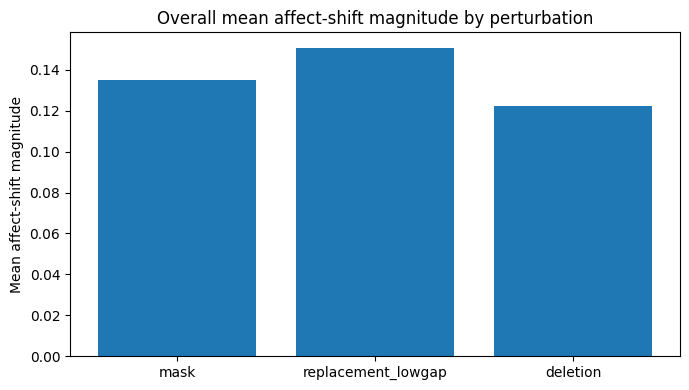

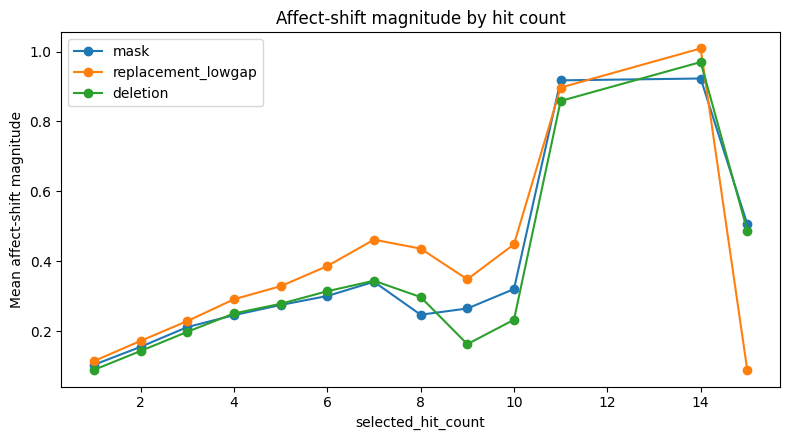

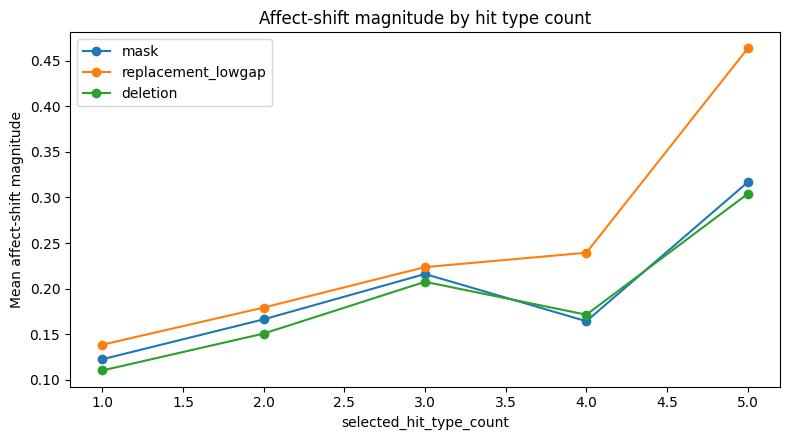

In [13]:
# Mean magnitude by perturbation overall
plot_df = summary.set_index("perturbation").loc[
    ["mask", "replacement_lowgap", "deletion"]
]

plt.figure(figsize=(7, 4))
plt.bar(plot_df.index, plot_df["mean_delta_affect_shift_mag"])
plt.ylabel("Mean affect-shift magnitude")
plt.title("Overall mean affect-shift magnitude by perturbation")
plt.tight_layout()
plt.savefig(figures_dir / "overall_mean_affect_shift_by_perturbation.png", dpi=200, bbox_inches="tight")
plt.show()

# Mean affect-shift magnitude split by selected_hit_count
for xcol, sdf, fname, title in [
    ("selected_hit_count", hit_count_summary, "affect_shift_by_hit_count.png", "Affect-shift magnitude by hit count"),
    ("selected_hit_type_count", hit_type_summary, "affect_shift_by_hit_type_count.png", "Affect-shift magnitude by hit type count"),
]:
    plt.figure(figsize=(8, 4.5))
    for pert in ["mask", "replacement_lowgap", "deletion"]:
        g = sdf[sdf["perturbation"] == pert]
        plt.plot(g[xcol], g["mean_delta_affect_shift_mag"], marker="o", label=pert)
    plt.xlabel(xcol)
    plt.ylabel("Mean affect-shift magnitude")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(figures_dir / fname, dpi=200, bbox_inches="tight")
    plt.show()

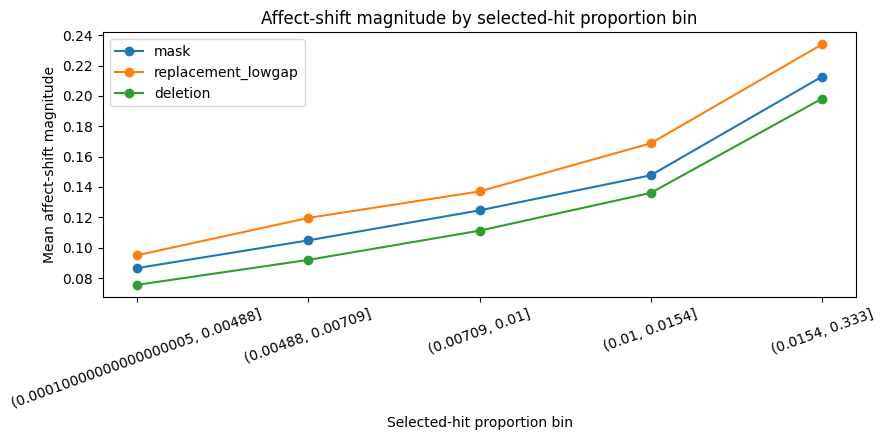

In [14]:
# Mean affect-shift magnitude split by selected_hit_prop_bin
prop_plot = hit_prop_bin_summary.copy()
prop_order = list(prop_plot["selected_hit_prop_bin"].drop_duplicates())
plt.figure(figsize=(9, 4.5))
for pert in ["mask", "replacement_lowgap", "deletion"]:
    g = prop_plot[prop_plot["perturbation"] == pert].copy()
    g["selected_hit_prop_bin"] = pd.Categorical(g["selected_hit_prop_bin"], categories=prop_order, ordered=True)
    g = g.sort_values("selected_hit_prop_bin")
    plt.plot(g["selected_hit_prop_bin"].astype(str), g["mean_delta_affect_shift_mag"], marker="o", label=pert)
plt.xlabel("Selected-hit proportion bin")
plt.ylabel("Mean affect-shift magnitude")
plt.title("Affect-shift magnitude by selected-hit proportion bin")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "affect_shift_by_hit_prop_bin.png", dpi=200, bbox_inches="tight")
plt.show()

## Save the standardized long-form comparison file

In [15]:
combined.to_csv(tables_dir / "combined_three_perturbation_results.csv", index=False)
paired_complete.to_csv(tables_dir / "paired_complete_results.csv")

print("Saved files:")
for p in sorted(tables_dir.glob("*")):
    print(" -", p.name)
for p in sorted(figures_dir.glob("*")):
    print(" -", p.name)

hit_count_summary.to_csv(tables_dir / "summary_by_hit_count_and_perturbation.csv", index=False)
hit_type_summary.to_csv(tables_dir / "summary_by_hit_type_count_and_perturbation.csv", index=False)
hit_prop_bin_summary.to_csv(tables_dir / "summary_by_hit_prop_bin_and_perturbation.csv", index=False)
stratified_pairwise.to_csv(tables_dir / "stratified_pairwise_comparisons.csv", index=False)

Saved files:
 - combined_three_perturbation_results.csv
 - correlations_by_perturbation.csv
 - dose_summary_by_perturbation.csv
 - friedman_three_condition_tests.csv
 - paired_complete_results.csv
 - pairwise_wilcoxon_comparisons.csv
 - stratified_pairwise_comparisons.csv
 - summary_by_hit_count_and_perturbation.csv
 - summary_by_hit_prop_bin_and_perturbation.csv
 - summary_by_hit_type_count_and_perturbation.csv
 - summary_by_perturbation.csv
 - affect_shift_by_hit_count.png
 - affect_shift_by_hit_prop_bin.png
 - affect_shift_by_hit_type_count.png
 - dose_response_shift_mag_deletion.png
 - dose_response_shift_mag_mask.png
 - dose_response_shift_mag_replacement_lowgap.png
 - mean_abs_delta_arousal_by_perturbation.png
 - mean_abs_delta_valence_by_perturbation.png
 - mean_shift_magnitude_by_perturbation.png
 - overall_mean_affect_shift_by_perturbation.png
